In [1]:
import mne

In [2]:
raw = mne.io.read_raw_bdf('./eeg_data/4063_0616/passive1.bdf', exclude='EXG8', preload=True)
raw.info

Extracting EDF parameters from /home/yi/Programs/analysis_gammacontrol/eeg_data/4063_0616/passive1.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 722943  =      0.000 ...   353.000 secs...


<Info | 7 non-empty values
 bads: []
 ch_names: Fp1, AF7, AF3, F1, F3, F5, F7, Fpz, FT7, FC5, FC3, FC1, C1, C3, ...
 chs: 71 EEG, 1 STIM
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 417.0 Hz
 meas_date: 2020-06-16 14:46:54 UTC
 nchan: 72
 projs: []
 sfreq: 2048.0 Hz
>

In [7]:
mne.find_events(raw)

200 events found
Event IDs: [1024 2048]


array([[ 94893,      0,   1024],
       [ 98005,      0,   1024],
       [101068,      0,   1024],
       [104130,      0,   2048],
       [107189,      0,   1024],
       [110328,      0,   1024],
       [113389,      0,   1024],
       [116449,      0,   1024],
       [119510,      0,   1024],
       [122571,      0,   1024],
       [125706,      0,   1024],
       [128767,      0,   1024],
       [131828,      0,   2048],
       [134888,      0,   1024],
       [137949,      0,   1024],
       [141084,      0,   2048],
       [144143,      0,   1024],
       [147203,      0,   1024],
       [150264,      0,   1024],
       [153325,      0,   1024],
       [156459,      0,   1024],
       [159520,      0,   1024],
       [162582,      0,   1024],
       [165640,      0,   1024],
       [168700,      0,   1024],
       [171836,      0,   1024],
       [174895,      0,   2048],
       [177954,      0,   1024],
       [181015,      0,   1024],
       [184076,      0,   1024],
       [18

Creating RawArray with float64 data, n_channels=64, n_times=1
    Range : 0 ... 0 =      0.000 ...     0.000 secs
Ready.


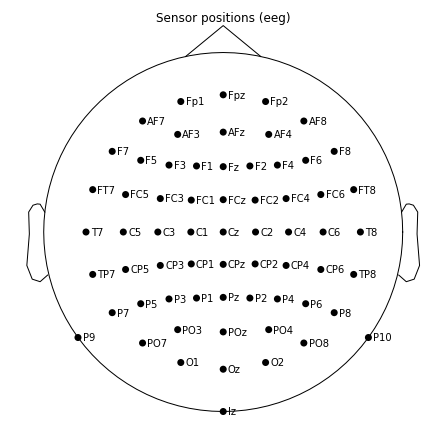

In [3]:
biosemi_montage = mne.channels.make_standard_montage('biosemi64')
_ = biosemi_montage.plot()

In [4]:
import json
with open('EXG_channels.json', 'r') as f:
    raw.set_channel_types(json.load(f))
raw.set_montage(biosemi_montage)

<RawEDF | passive1.bdf, 72 x 722944 (353.0 s), ~397.3 MB, data loaded>

In [5]:
raw.filter(1, 100)
raw.notch_filter(60)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 6759 samples (3.300 sec)

Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandw

<RawEDF | passive1.bdf, 72 x 722944 (353.0 s), ~397.3 MB, data loaded>

In [11]:
_ = raw.plot(start=0.0, duration=10.0)#events=mne.find_events(raw))

ValueError: The number of FixedLocator locations (20), usually from a call to set_ticks, does not match the number of ticklabels (1).